In [16]:
import numpy as np
import pandas as pd
import seaborn as sns

In [17]:
df = pd.read_csv("weight-height.csv")
df.sample(5)

,Gender,Height,Weight
411,Male,67.583941,179.937011
7724,Female,61.383461,125.754422
7002,Female,61.991074,131.410732
8280,Female,66.988613,156.256876
6098,Female,66.813681,168.597929


In [18]:
df.shape

(10000, 3)

In [19]:
df["Height"].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

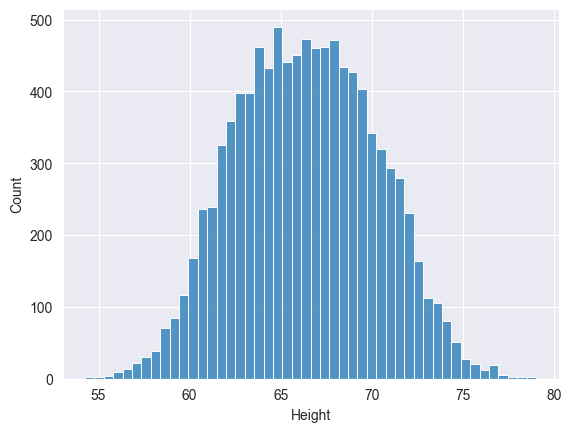

In [20]:
sns.histplot(df["Height"])

<Axes: ylabel='Height'>

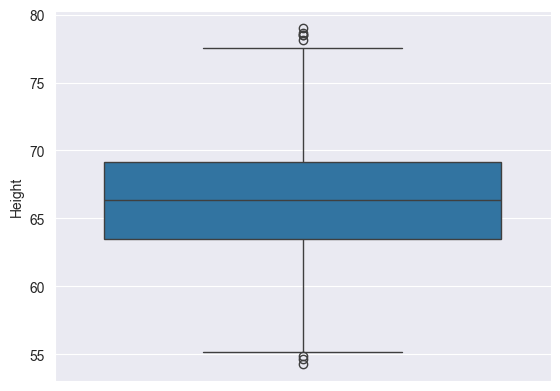

In [21]:
sns.boxplot(df['Height'])

In [22]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

np.float64(74.7857900583366)

In [23]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

np.float64(58.13441158671655)

In [24]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]

In [25]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

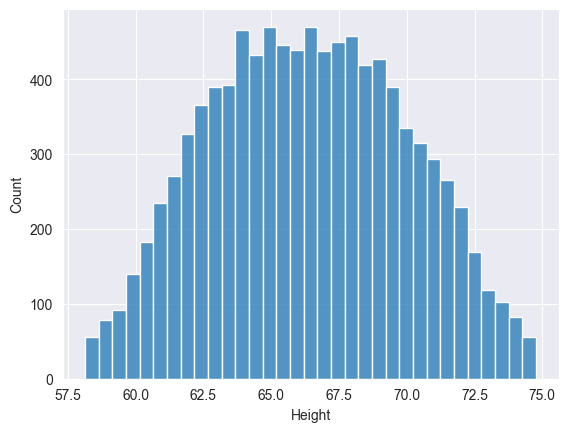

In [26]:
sns.histplot(new_df['Height'])

<Axes: ylabel='Height'>

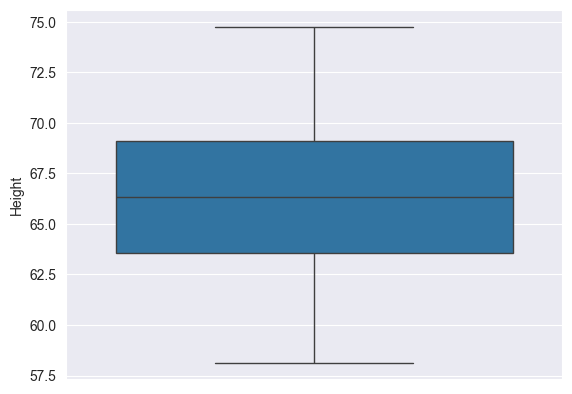

In [27]:
sns.boxplot(new_df['Height'])

## Capping --> Winsorization

In [28]:
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [29]:
df.shape

(10000, 3)

In [30]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64